# Bibliotecas Usadas

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

# Parte 2


## A2 ) treinamento no Pytorch


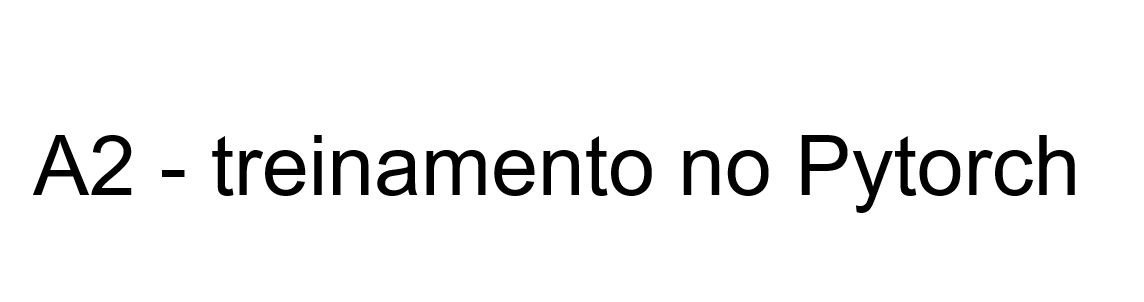

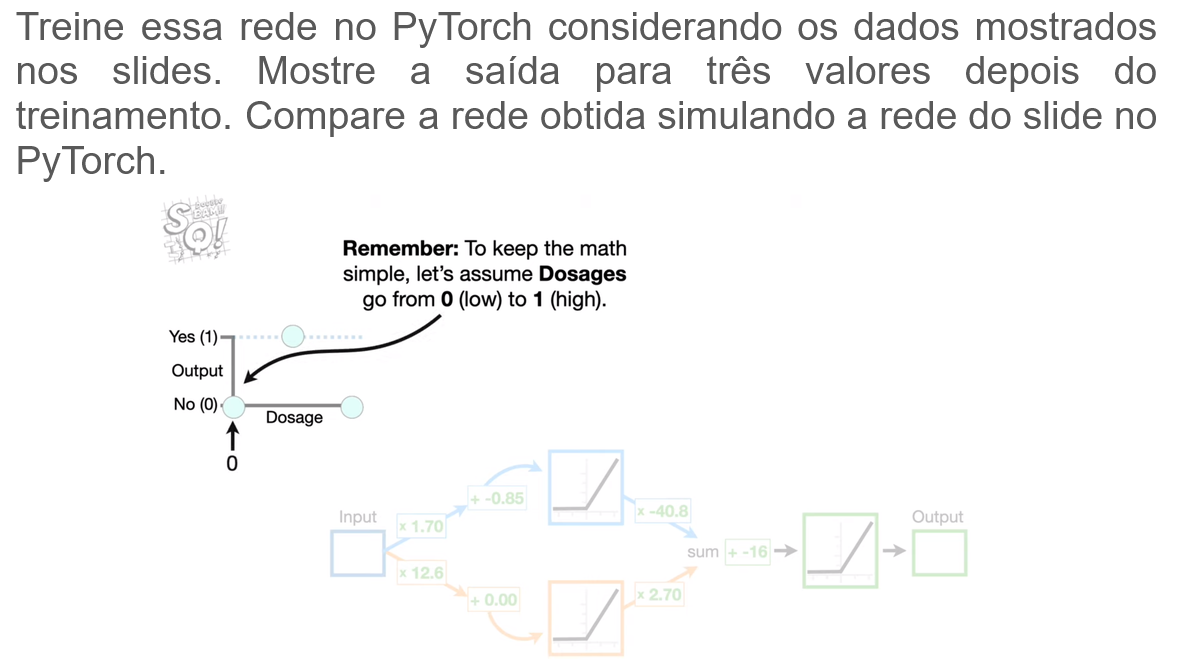

### Conceitos

#### Rede Neural Feedforward
Arquitetura onde a informação flui em uma única direção: da entrada, passando por uma ou mais camadas ocultas, até a saída — sem realimentação (diferente de uma RNN). Aqui: 1 entrada → 2 neurônios ocultos → 1 saída.

#### Pesos e Viés (*Weights* e *Bias*)
Os **pesos** multiplicam os valores de entrada, controlando sua influência no resultado. O **viés** é uma constante somada, que desloca o resultado independentemente da entrada. São os parâmetros que a rede ajusta durante o treinamento.

#### Função de Ativação (ReLU)
`ReLU(x) = max(0, x)`. Introduz não linearidade na rede, permitindo que ela aprenda padrões mais complexos do que uma simples combinação linear (como o "pico" ou "bloco" de eficácia visto no exercício).

#### Forward Pass (Propagação Direta)
É o cálculo da saída da rede a partir de uma entrada, percorrendo camada por camada (entrada → soma ponderada → ativação → próxima camada), até chegar à predição final.

#### Função de Perda (*Loss Function*) — MSE
O **Erro Quadrático Médio** (*Mean Squared Error*) mede o quão distante a predição da rede está do valor real (alvo):

`MSE = média((predição - alvo)²)`.

Quanto menor, melhor o ajuste da rede aos dados.

#### Backpropagation
Algoritmo que calcula o gradiente da função de perda em relação a cada peso e viés da rede, "propagando" o erro da saída de volta para as camadas anteriores. É o que permite saber **em que direção** ajustar cada parâmetro.

#### Gradiente Descendente e Otimizador (Adam)
O gradiente indica a direção de maior crescimento do erro; por isso os pesos são atualizados na direção **oposta** ao gradiente, reduzindo a perda a cada passo. O **Adam** é uma variante do gradiente descendente que adapta a taxa de aprendizado automaticamente para cada parâmetro, geralmente convergindo mais rápido.

#### Época (*Epoch*)
Uma passagem completa do processo (forward pass → cálculo da perda → backpropagation → atualização dos pesos) usando todo o conjunto de dados de treino. Repetimos esse processo por várias épocas até a rede convergir.

#### Taxa de Aprendizado (*Learning Rate*)
Hiperparâmetro que controla o "tamanho do passo" dado a cada atualização dos pesos. Muito alta pode fazer o treinamento divergir; muito baixa pode deixá-lo lento demais.

#### Inicialização Aleatória e Semente (*Seed*)
Antes do treinamento, os pesos começam com valores aleatórios (diferente da rede do slide, que já vem "pronta"). A **semente aleatória** (`torch.manual_seed`) fixa essa aleatoriedade, garantindo que o experimento seja reproduzível — e, no caso de redes com ReLU, evita cair em más inicializações onde o gradiente fica preso em zero (neurônios "mortos").

#### Comparação de Modelos / Generalização
Duas redes podem ter **exatamente a mesma arquitetura** e ainda representar funções completamente diferentes, dependendo apenas dos pesos aprendidos. Comparar a rede treinada com a rede de referência (pesos prontos do slide) mostra como o resultado final depende diretamente dos dados e rótulos usados no treinamento — não só da estrutura da rede.

### Código

#### Rede Neural do Exemplo

In [ ]:
class RedeSlide(nn.Module):
    def __init__(self):
        super().__init__()
        # Camada oculta: 1 entrada -> 2 neuronios
        self.hidden = nn.Linear(1, 2)
        with torch.no_grad():
            # peso do caminho azul
            self.hidden.weight = nn.Parameter(torch.tensor([[1.70], [12.6]]))
            # peso do caminho laranja
            self.hidden.bias = nn.Parameter(torch.tensor([-0.85, 0.00]))

        # Camada de saida: 2 neuronios -> 1 saida
        self.output = nn.Linear(2, 1)
        with torch.no_grad():
            self.output.weight = nn.Parameter(torch.tensor([[-40.8, 2.70]]))
            self.output.bias = nn.Parameter(torch.tensor([-16.0]))

    def forward(self, x):
        # ativacao ReLU nos dois neuronios ocultos
        h = F.relu(self.hidden(x))
        # ativacao ReLU tambem na saida
        saida = F.relu(self.output(h))
        return saida

rede_slide = RedeSlide()

#### Saída

In [ ]:
# Saída da rede do slide para as dosagens dadas

dosagens = torch.tensor([[0.0], [0.2], [0.4], [0.6], [0.8], [1.0]])

with torch.no_grad():
    saida_slide = rede_slide(dosagens)

print("Dosagem -> Saída da rede do slide (sem treinamento, pesos prontos)")
for d, s in zip(dosagens, saida_slide):
    print(f"  {d.item():.1f} -> {s.item():.4f}")

Dosagem -> Saída da rede do slide (sem treinamento, pesos prontos)
  0.0 -> 0.0000
  0.2 -> 0.0000
  0.4 -> 0.0000
  0.6 -> 0.0000
  0.8 -> 0.0000
  1.0 -> 0.0000


#### Avaliação da Rede

In [ ]:
# Avaliando a rede do slide numa grade mais fina

# 101 pontos entre 0 e 1
grade_fina = torch.linspace(0, 1, 101).unsqueeze(1)

with torch.no_grad():
    saida_fina = rede_slide(grade_fina)

pico_idx = torch.argmax(saida_fina)
print(f"Pico de eficácia da rede do slide ocorre em dosagem = {grade_fina[pico_idx].item():.2f}, "
      f"com saída = {saida_fina[pico_idx].item():.4f}")
print("Fora dessa região estreita, a saída é praticamente 0.")

Pico de eficácia da rede do slide ocorre em dosagem = 0.50, com saída = 1.0100
Fora dessa região estreita, a saída é praticamente 0.


#### Dados de Treinamento

In [ ]:
# Dados de treinamento
dosagens_treino = torch.tensor([[0.0], [0.2], [0.4], [0.6], [0.8], [1.0]])
eficacia_alvo   = torch.tensor([[0.0], [0.0], [1.0], [1.0], [0.0], [0.0]])

#### Treinamento

In [ ]:
# Rede treinável (mesma arquitetura, pesos aleatórios)
class RedeTreinavel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(1, 2)   # 1 entrada -> 2 neuronios ocultos
        self.output = nn.Linear(2, 1)   # 2 neuronios -> 1 saida

    def forward(self, x):
        h = F.relu(self.hidden(x))
        saida = F.relu(self.output(h))
        return saida

# fixando a semente aleatória para o resultado ser reprodutível
torch.manual_seed(5)
rede_treinavel = RedeTreinavel()

In [ ]:
# Loop de treinamento

otimizador = torch.optim.Adam(rede_treinavel.parameters(), lr=0.05)
funcao_perda = nn.MSELoss()   # erro quadrático médio (regressão)

num_epocas = 3000
historico_perda = []

for epoca in range(num_epocas):
    # zera os gradientes acumulados
    otimizador.zero_grad()
    # forward pass
    predicao = rede_treinavel(dosagens_treino)
    # calcula o erro
    perda = funcao_perda(predicao, eficacia_alvo)
    # backpropagation
    perda.backward()
    # atualiza os pesos
    otimizador.step()

    historico_perda.append(perda.item())
    if epoca % 500 == 0:
        print(f"Época {epoca:4d} | Perda (MSE) = {perda.item():.6f}")

print(f"\nPerda final = {perda.item():.6f}")

Época    0 | Perda (MSE) = 0.331568
Época  500 | Perda (MSE) = 0.000000
Época 1000 | Perda (MSE) = 0.000000
Época 1500 | Perda (MSE) = 0.000000
Época 2000 | Perda (MSE) = 0.000000
Época 2500 | Perda (MSE) = 0.000000

Perda final = 0.000000


#### Gráfico

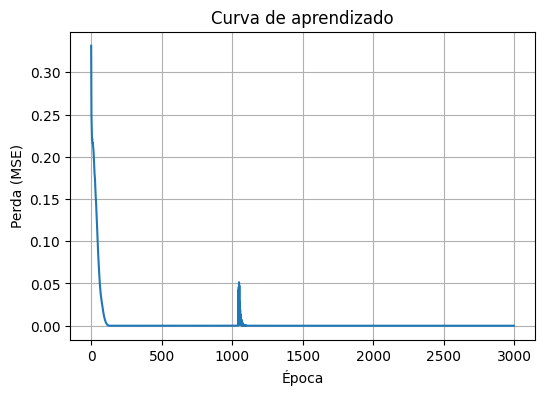

In [ ]:
# Curva de aprendizado (perda x época)
plt.figure(figsize=(6, 4))
plt.plot(historico_perda)
plt.xlabel("Época")
plt.ylabel("Perda (MSE)")
plt.title("Curva de aprendizado")
plt.grid(True)
plt.show()

#### 3 Valores de Treinamento

In [ ]:
# Saída da rede treinada para 3 valores pedidos
tres_valores = torch.tensor([[0.0], [0.4], [1.0]])

with torch.no_grad():
    saida_tres_valores = rede_treinavel(tres_valores)

print("Saída da rede TREINADA:")
for d, s in zip(tres_valores, saida_tres_valores):
    rotulo = "Yes (1)" if s.item() >= 0.5 else "No (0)"
    print(f"  Dosagem {d.item():.1f} -> saída = {s.item():.4f}  ({rotulo})")

Saída da rede TREINADA:
  Dosagem 0.0 -> saída = 0.0000  (No (0))
  Dosagem 0.4 -> saída = 1.0000  (Yes (1))
  Dosagem 1.0 -> saída = 0.0000  (No (0))


## B2 ) PyTorch e redes de múltiplas entradas e saídas


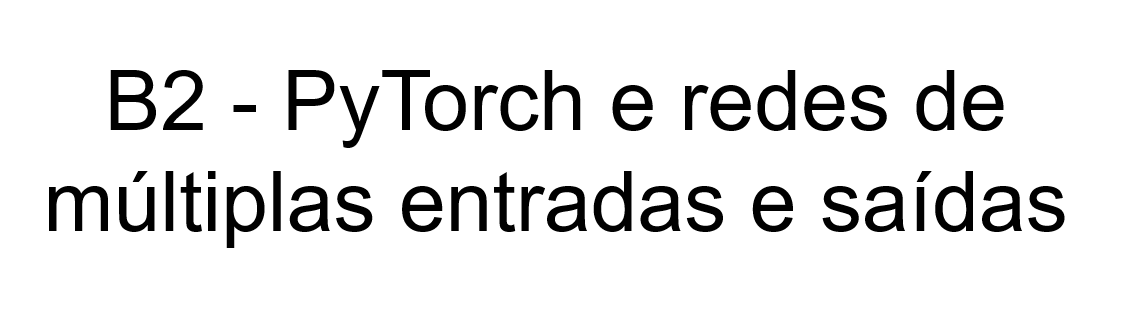

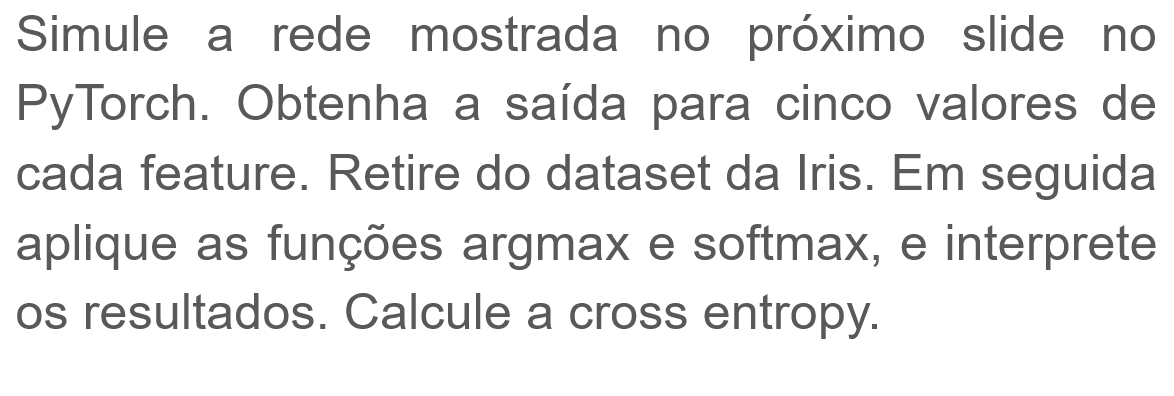

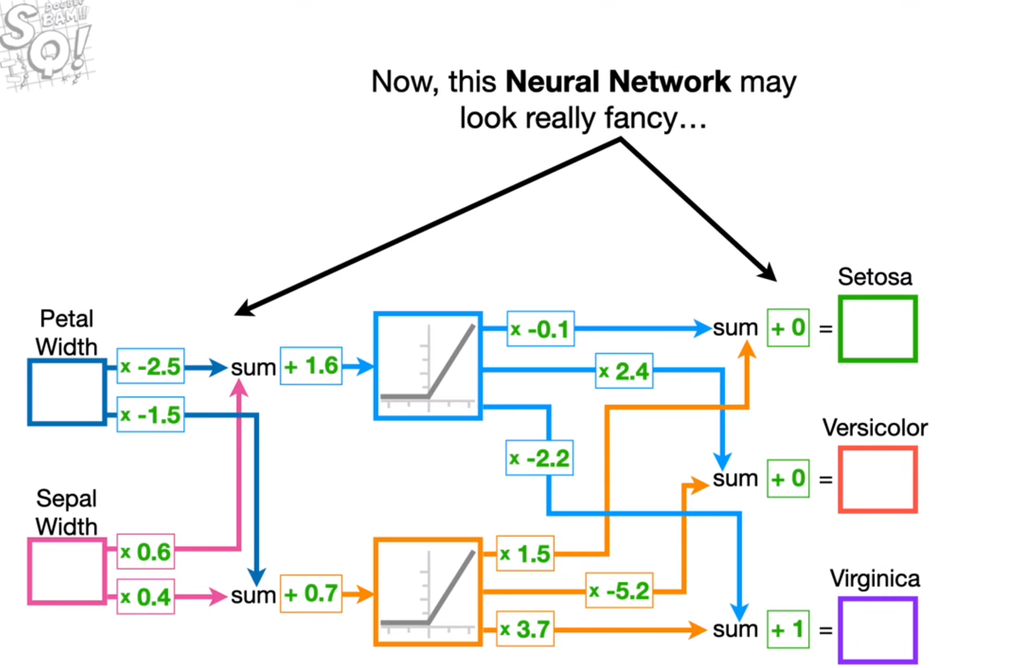

### Código

#### Simulando a Rede

In [ ]:
class IrisNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Camada de entrada -> oculta (2 entradas -> 2 neuronios)
        # Ordem das entradas: [PetalWidth, SepalWidth]
        self.hidden = nn.Linear(2, 2)
        with torch.no_grad():
            # h1 (azul):  PetalWidth*(-2.5) + SepalWidth*(0.6) + 1.6
            # h2 (laranja): PetalWidth*(-1.5) + SepalWidth*(0.4) + 0.7
            self.hidden.weight = nn.Parameter(torch.tensor([
                [-2.5,  0.6],   # h1
                [-1.5,  0.4],   # h2
            ]))
            self.hidden.bias = nn.Parameter(torch.tensor([1.6, 0.7]))

        # Camada oculta -> saida (2 neuronios -> 3 classes)
        self.output = nn.Linear(2, 3)
        with torch.no_grad():
            # Setosa     = h1*(-0.1) + h2*(-5.2) + 0
            # Versicolor = h1*( 2.4) + h2*( 1.5) + 0
            # Virginica  = h1*(-2.2) + h2*( 3.7) + 1
            self.output.weight = nn.Parameter(torch.tensor([
                [-0.1, -5.2],   # Setosa
                [ 2.4,  1.5],   # Versicolor
                [-2.2,  3.7],   # Virginica
            ]))
            self.output.bias = nn.Parameter(torch.tensor([0.0, 0.0, 1.0]))

    def forward(self, x):
        # ativacao ReLU nos dois neuronios ocultos
        h = F.relu(self.hidden(x))
        # logits (saida "crua", sem softmax)
        out = self.output(h)
        return out


net = IrisNet()

#### Amostragem

In [ ]:
iris = load_iris()
feature_names = iris.feature_names
idx_petal_width = feature_names.index('petal width (cm)')
idx_sepal_width = feature_names.index('sepal width (cm)')

# pegamos uma amostra de cada uma das 3 classes + mais 2, para ficar variado

# indices no dataset original
sample_idx = [0, 1, 50, 51, 100]
X_full = iris.data[sample_idx]

# 0 = setosa, 1 = versicolor, 2 = virginica
y_true = iris.target[sample_idx]
class_names = iris.target_names

X = torch.tensor(X_full[:, [idx_petal_width, idx_sepal_width]], dtype=torch.float32)
y = torch.tensor(y_true, dtype=torch.long)

print("Amostras escolhidas (Petal Width, Sepal Width) e classe real:")
for i in range(len(sample_idx)):
    print(f"  Amostra {i+1}: PetalWidth={X[i,0]:.1f}  SepalWidth={X[i,1]:.1f}  "
          f"-> classe real = {class_names[y_true[i]]}")



Amostras escolhidas (Petal Width, Sepal Width) e classe real:
  Amostra 1: PetalWidth=0.2  SepalWidth=3.5  -> classe real = setosa
  Amostra 2: PetalWidth=0.2  SepalWidth=3.0  -> classe real = setosa
  Amostra 3: PetalWidth=1.4  SepalWidth=3.2  -> classe real = versicolor
  Amostra 4: PetalWidth=1.5  SepalWidth=3.2  -> classe real = versicolor
  Amostra 5: PetalWidth=2.5  SepalWidth=3.3  -> classe real = virginica


#### Logits

In [ ]:
with torch.no_grad():
    logits = net(X)

print("\nSaida da rede (logits, antes do softmax):")
print(logits)



Saida da rede (logits, antes do softmax):
tensor([[-9.6800e+00,  1.0380e+01,  6.2000e-01],
        [-8.6100e+00,  9.3600e+00,  5.4000e-01],
        [-2.0000e-03,  4.8000e-02,  9.5600e-01],
        [ 0.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  1.0000e+00]])


#### Sotfmax e Argmax

In [ ]:
probs = F.softmax(logits, dim=1)
preds = torch.argmax(probs, dim=1)

print("\nProbabilidades (softmax):")
print(probs)

print("\nClasse prevista (argmax):")
for i in range(len(sample_idx)):
    print(f"  Amostra {i+1}: previsto = {class_names[preds[i]]}  "
          f"(prob={probs[i, preds[i]]:.4f})  | real = {class_names[y_true[i]]}")


Probabilidades (softmax):
tensor([[1.9410e-09, 9.9994e-01, 5.7711e-05],
        [1.5691e-08, 9.9985e-01, 1.4773e-04],
        [2.1470e-01, 2.2570e-01, 5.5960e-01],
        [2.1194e-01, 2.1194e-01, 5.7612e-01],
        [2.1194e-01, 2.1194e-01, 5.7612e-01]])

Classe prevista (argmax):
  Amostra 1: previsto = versicolor  (prob=0.9999)  | real = setosa
  Amostra 2: previsto = versicolor  (prob=0.9999)  | real = setosa
  Amostra 3: previsto = virginica  (prob=0.5596)  | real = versicolor
  Amostra 4: previsto = virginica  (prob=0.5761)  | real = versicolor
  Amostra 5: previsto = virginica  (prob=0.5761)  | real = virginica


#### Cross-Entropy

In [ ]:
# nn.CrossEntropyLoss aplica log-softmax internamente, entao se usa os logits
loss_fn = nn.CrossEntropyLoss()
loss_medio = loss_fn(logits, y)

loss_fn_none = nn.CrossEntropyLoss(reduction='none')
loss_individual = loss_fn_none(logits, y)

print("\nCross entropy por amostra:")
for i in range(len(sample_idx)):
    print(f"  Amostra {i+1}: CE = {loss_individual[i]:.4f}")

print(f"\nCross entropy media (loss do lote): {loss_medio:.4f}")



Cross entropy por amostra:
  Amostra 1: CE = 20.0601
  Amostra 2: CE = 17.9701
  Amostra 3: CE = 1.4885
  Amostra 4: CE = 1.5514
  Amostra 5: CE = 0.5514

Cross entropy media (loss do lote): 8.3243


## C2 ) PyTorch e cross entropy

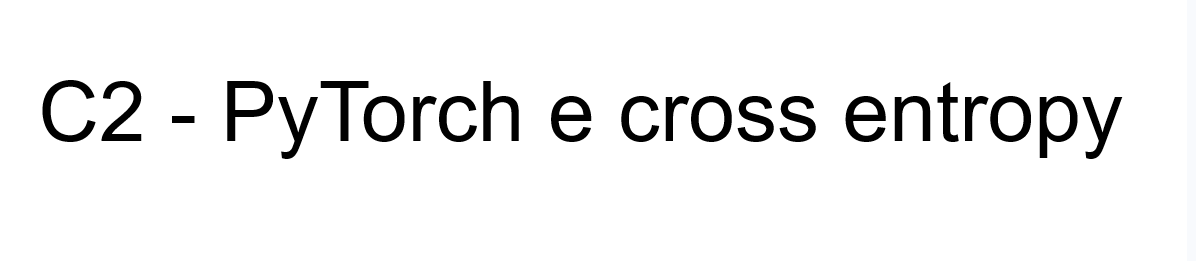

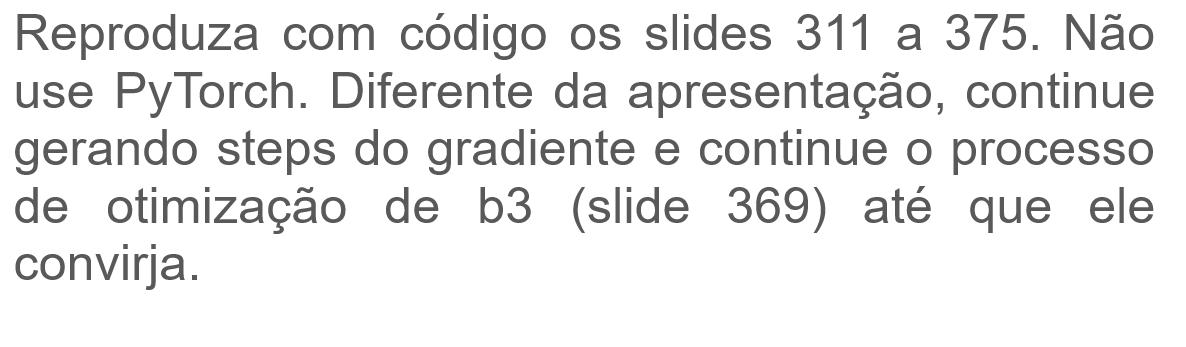

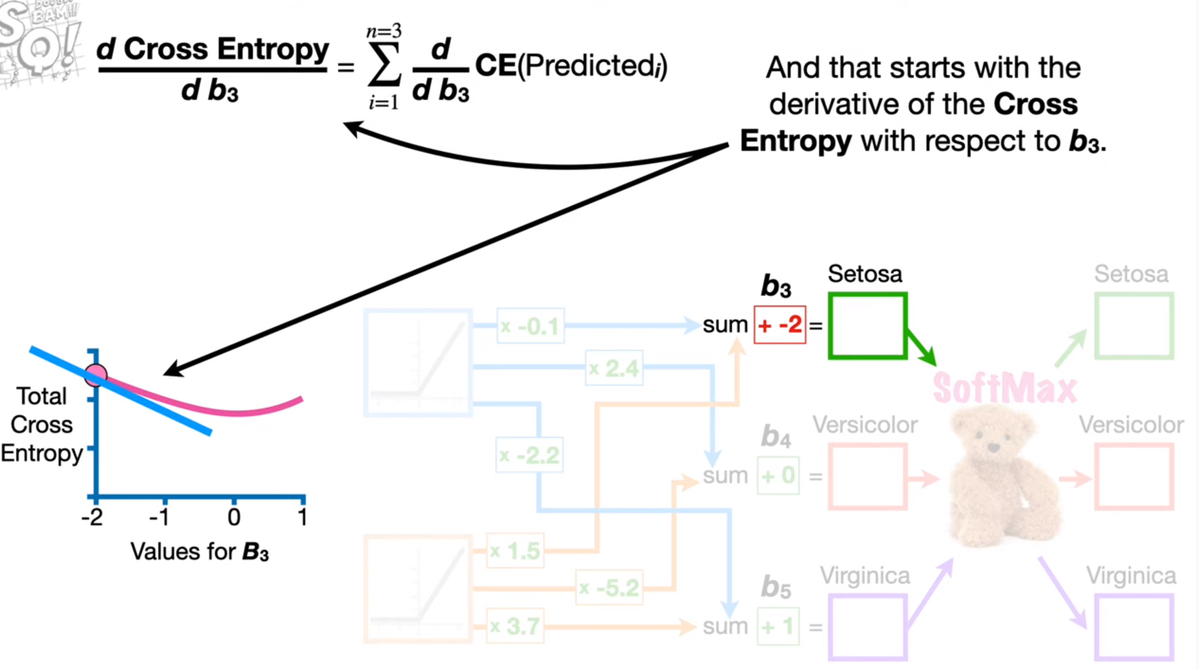

### Conceitos

#### Softmax

* **O que é:** É a função que transforma os números brutos gerados pela rede neural (chamados de *logits*) em **probabilidades** reais que ficam entre 0% e 100% e, somadas, resultam exatamente em 1. Ela é usada na última camada para classificação de múltiplas categorias (como decidir entre as três espécies de flores).
* **Fórmula:**
$$P(y = c) = \frac{e^{z_c}}{\sum_{j=1}^{K} e^{z_j}}$$



*(Onde $z_c$ é o score da classe atual e o denominador é a soma dos scores de todas as classes transformados por exponencial).*

---

#### Entropia Cruzada (Cross Entropy)

* **O que é:** É a **função de custo (ou perda)**. Ela mede o tamanho do "vacilo" da rede neural. Quanto mais distante a previsão da rede estiver da realidade, maior será o valor da Entropia Cruzada. O objetivo do treinamento é fazer esse valor chegar o mais próximo possível de zero.
* **Fórmula (para uma amostra):**
$$\text{CE} = -\sum_{i=1}^{K} y_i \log(p_i)$$



*(Onde $y_i$ é a resposta real [0 ou 1] e $p_i$ é a probabilidade prevista pela Softmax).*

---

#### Gradiente (Derivative / Gradient)

* **O que é:** Na prática, é uma taxa de variação. O gradiente nos diz o quanto o erro total (Entropia Cruzada) vai subir ou descer se alterarmos ligeiramente o valor de um parâmetro (como o $b_3$). Se o gradiente for negativo, significa que aumentar o parâmetro vai diminuir o erro.
* **Fórmula (simplificada para o viés nos slides):**
$$\frac{d\text{CE}}{db_3} = \sum_{i=1}^{n} (p_i - y_i)$$



*(Basicamente: a probabilidade prevista menos a resposta real acumulada para as amostras).*

---

#### Tamanho do Passo (Step Size) e Taxa de Aprendizado

* **O que é:** Indica o "tamanho da passada" que daremos na direção de um erro menor. Se o passo for grande demais, podemos passar direto pelo ponto ideal; se for pequeno demais, o código vai demorar uma eternidade para convergir. Nos slides, a taxa de aprendizado (Learning Rate) padrão usada é 1.
* **Fórmula:**
$$\text{Step Size} = \text{Gradiente} \times \text{Learning Rate}$$



---

#### Gradiente Descendente (Gradient Descent)

* **O que é:** É o processo repetitivo (o algoritmo de otimização) de usar o *Step Size* calculado para atualizar os parâmetros do modelo passo a passo, descendo a ladeira do gráfico de erro até encontrar o ponto mais baixo possível (mínimo global).
* **Fórmula de Atualização:**
$$\text{Novo } b_3 = b_3 - \text{Step Size}$$



---

#### Viés (Bias - $b_3$)

* **O que é:** É um parâmetro ajustável que funciona como um "ajuste fino" ou deslocamento fixo adicionado aos neurônios. Ele permite que a rede desloque a curva de ativação para cima, para baixo, para a esquerda ou para a direita, ajudando a ajustar as previsões independentemente dos dados de entrada.

### Código

#### Configurações iniciais

In [ ]:
# Configurações iniciais (Slide 369)
b3 = -2.0
learning_rate = 1.0
tolerance = 1e-6
max_iter = 100
# Probabilidades iniciais quando b3 = -2
p1_init, p2_init, p3_init = 0.15, 0.04, 0.04

#### Cálculo das Constantes

In [ ]:
# Cálculo das constantes de proporção C_i para cada uma das 3 amostras
# Deduzido da fórmula: C_i = ((1 - p_i) / p_i) * e^(b3)
c1 = ((1 - p1_init) / p1_init) * np.exp(b3)
c2 = ((1 - p2_init) / p2_init) * np.exp(b3)
c3 = ((1 - p3_init) / p3_init) * np.exp(b3)

print("   OTIMIZAÇÃO DO PARÂMETRO b3 ATÉ A CONVERGÊNCIA  ")
print("==================================================")
print(f"Constantes de proporção dos dados:")
print(f"C1 (Setosa): {c1:.4f} | C2 (Versicolor): {c2:.4f} | C3 (Virginica): {c3:.4f}\n")

# Loop de Otimização por Gradiente Descendente
for step in range(1, max_iter + 1):
    # Calcular as probabilidades atuais usando a Softmax simplificada
    p1 = 1 / (1 + c1 * np.exp(-b3))
    p2 = 1 / (1 + c2 * np.exp(-b3))
    p3 = 1 / (1 + c3 * np.exp(-b3))

    # Calcular o valor da Entropia Cruzada Total (apenas a parte dependente de b3)
    loss = -np.log(p1) - np.log(1 - p2) - np.log(1 - p3)

    # Calcular o gradiente total em relação a b3 (conforme a fórmula dos slides)
    gradient = (p1 - 1) + p2 + p3

    # Exibir o status de progresso dos primeiros passos e marcos de convergência
    if step <= 5 or step % 5 == 0:
        print(f"Passo {step:02d}:")
        print(f"  b3 atual      = {b3:.4f}")
        print(f"  Predições (p) = [F1: {p1:.3f}, F2: {p2:.3f}, F3: {p3:.3f}]")
        print(f"  Gradiente     = {gradient:.4f}")
        print(f"  Loss (CE)     = {loss:.4f}")
        print("-" * 40)

    # Atualização do parâmetro b3: b3_novo = b3_atual - (learning_rate * gradiente)
    b3_new = b3 - learning_rate * gradient

    # Critério de parada: se a variação for menor que o nosso limite (tolerance)
    if abs(b3_new - b3) < tolerance:
        print(f"\n Otimização convergiu com sucesso no Passo {step}!")
        print(f"-> Valor ideal final para b3: {b3_new:.4f}")
        print(f"-> Gradiente final estabilizado: {gradient:.6f}")
        break

    b3 = b3_new

   OTIMIZAÇÃO DO PARÂMETRO b3 ATÉ A CONVERGÊNCIA  
Constantes de proporção dos dados:
C1 (Setosa): 0.7669 | C2 (Versicolor): 3.2480 | C3 (Virginica): 3.2480

Passo 01:
  b3 atual      = -2.0000
  Predições (p) = [F1: 0.150, F2: 0.040, F3: 0.040]
  Gradiente     = -0.7700
  Loss (CE)     = 1.9788
----------------------------------------
Passo 02:
  b3 atual      = -1.2300
  Predições (p) = [F1: 0.276, F2: 0.083, F3: 0.083]
  Gradiente     = -0.5589
  Loss (CE)     = 1.4598
----------------------------------------
Passo 03:
  b3 atual      = -0.6711
  Predições (p) = [F1: 0.400, F2: 0.136, F3: 0.136]
  Gradiente     = -0.3281
  Loss (CE)     = 1.2087
----------------------------------------
Passo 04:
  b3 atual      = -0.3430
  Predições (p) = [F1: 0.481, F2: 0.179, F3: 0.179]
  Gradiente     = -0.1608
  Loss (CE)     = 1.1279
----------------------------------------
Passo 05:
  b3 atual      = -0.1822
  Predições (p) = [F1: 0.521, F2: 0.204, F3: 0.204]
  Gradiente     = -0.0708
  Loss (

## D2 )  Pytorch e CNN


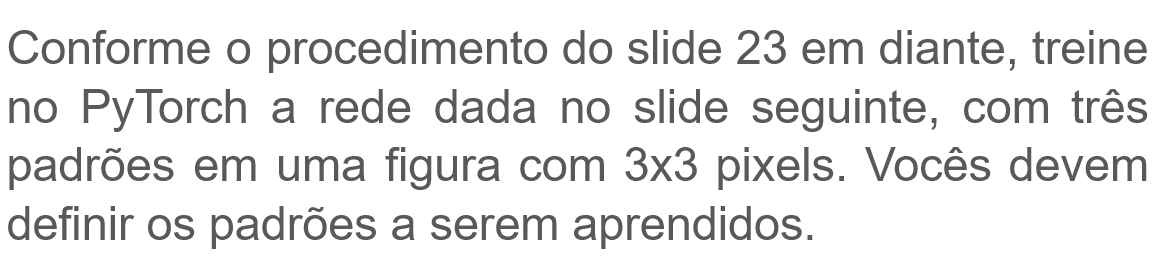

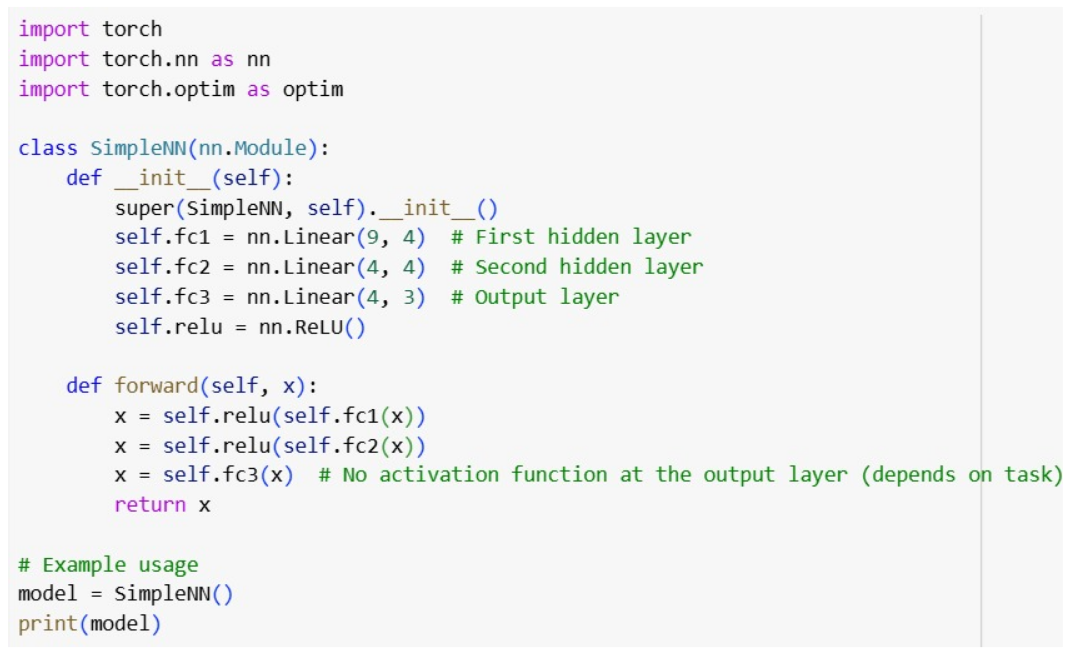

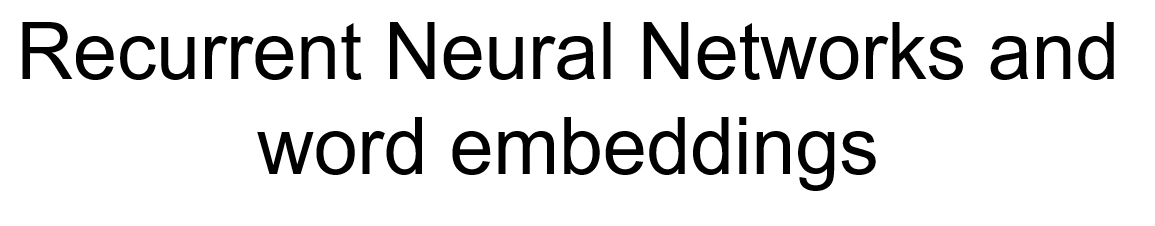

### Redes Neurais Artificiais (ANN)

Uma Rede Neural Artificial é um modelo computacional inspirado no funcionamento dos neurônios biológicos. Ela é composta por camadas de neurônios artificiais que recebem entradas, realizam cálculos e produzem uma saída.

Neste exercício foi utilizada uma rede do tipo **Perceptron Multicamadas (MLP)**.

---

### Camadas da Rede

A rede utilizada possui:

- Camada de entrada: 9 neurônios (imagem 3×3)
- Primeira camada oculta: 4 neurônios
- Segunda camada oculta: 4 neurônios
- Camada de saída: 3 neurônios (uma classe para cada padrão)

Arquitetura:

9 → 4 → 4 → 3

---

### Pixels como Entrada

Cada imagem possui dimensão 3×3.

Como cada pixel possui apenas dois valores (0 ou 1), ela pode ser representada como um vetor com 9 elementos.

Exemplo:

1 0 1

0 1 0

1 0 1

↓

[1,0,1,0,1,0,1,0,1]

---

### Forward Propagation

No processo de Forward Propagation, os dados percorrem toda a rede:

Entrada → Camadas Ocultas → Saída

Ao final, a rede produz uma previsão para a classe da imagem.

---

### Função de Custo (Loss Function)

A função de custo mede o erro cometido pela rede.

Neste exercício será utilizada a **CrossEntropyLoss**, adequada para problemas de classificação.

Quanto menor a perda, melhor o desempenho da rede.

---

### Gradiente Descendente

O Gradiente Descendente é o algoritmo responsável por atualizar os pesos da rede.

Seu objetivo é minimizar a função de custo, ajustando os pesos na direção em que o erro diminui.

---

### Backpropagation

Após calcular o erro, a técnica de Backpropagation calcula como cada peso contribuiu para esse erro.

Essas informações são utilizadas pelo Gradiente Descendente para atualizar os pesos da rede.

---

### Épocas (Epochs)

Uma época corresponde a uma passagem completa por todo o conjunto de treinamento.

A cada época:

- a rede realiza uma previsão;
- calcula o erro;
- ajusta os pesos.

Com várias épocas, espera-se que a perda diminua e a precisão aumente.

### Código

#### Padrões

In [ ]:
# Classe 0
# Letra: X
padrao_x = [
    1,0,1,
    0,1,0,
    1,0,1
]

# Classe 1
# Simbolo: +
padrao_mais = [
    0,1,0,
    1,1,1,
    0,1,0
]

# Classe 2
# Forma: Quadrado
padrao_quadrado = [
    1,1,1,
    1,0,1,
    1,1,1
]

X = torch.tensor([padrao_x, padrao_mais, padrao_quadrado], dtype=torch.float32)

y = torch.tensor([
    0,
    1,
    2
], dtype=torch.long)

#### Rede Neural

In [ ]:
class Rede_Neural(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(9,4)

        self.fc2 = nn.Linear(4,4)

        self.fc3 = nn.Linear(4,3)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = self.relu(self.fc1(x))

        x = self.relu(self.fc2(x))

        x = self.fc3(x)

        return x

modelo = Rede_Neural()

print(modelo)

Rede_Neural(
  (fc1): Linear(in_features=9, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=4, bias=True)
  (fc3): Linear(in_features=4, out_features=3, bias=True)
  (relu): ReLU()
)


#### Função de Perda e Otimização

In [ ]:
funcao_perda = nn.CrossEntropyLoss()

otimizador = optim.SGD(
    modelo.parameters(),
    lr=0.01
)

#### Treinamento

In [ ]:
# TREINAMENTO

epocas = 3000

for epoca in range(epocas):

    otimizador.zero_grad()

    previsoes = modelo(X)

    perda = funcao_perda(previsoes,y)

    perda.backward()

    otimizador.step()

    if (epoca+1)%50 == 0:

        print(f"Época {epoca+1} - Perda = {perda.item():.5f}")

Época 50 - Perda = 1.08455
Época 100 - Perda = 1.06739
Época 150 - Perda = 1.04516
Época 200 - Perda = 1.01861
Época 250 - Perda = 0.98247
Época 300 - Perda = 0.93797
Época 350 - Perda = 0.88388
Época 400 - Perda = 0.81905
Época 450 - Perda = 0.74548
Época 500 - Perda = 0.67129
Época 550 - Perda = 0.60493
Época 600 - Perda = 0.55187
Época 650 - Perda = 0.51142
Época 700 - Perda = 0.47916
Época 750 - Perda = 0.45052
Época 800 - Perda = 0.42081
Época 850 - Perda = 0.38516
Época 900 - Perda = 0.34329
Época 950 - Perda = 0.29486
Época 1000 - Perda = 0.24269
Época 1050 - Perda = 0.19191
Época 1100 - Perda = 0.14835
Época 1150 - Perda = 0.11399
Época 1200 - Perda = 0.08855
Época 1250 - Perda = 0.07019
Época 1300 - Perda = 0.05686
Época 1350 - Perda = 0.04710
Época 1400 - Perda = 0.03979
Época 1450 - Perda = 0.03416
Época 1500 - Perda = 0.02976
Época 1550 - Perda = 0.02624
Época 1600 - Perda = 0.02338
Época 1650 - Perda = 0.02100
Época 1700 - Perda = 0.01902
Época 1750 - Perda = 0.01733
Época

#### Teste

In [ ]:
# TESTE DA REDE

modelo.eval()

with torch.no_grad():

    saida = modelo(X)

    previsao = torch.argmax(saida,dim=1)

print("\nClasses previstas:")

print(previsao)


Classes previstas:
tensor([0, 1, 2])


#### Probabilidades

In [ ]:
# PROBABILIDADES

softmax = nn.Softmax(dim=1)

probabilidades = softmax(saida)

print(probabilidades)

tensor([[9.9632e-01, 3.0650e-07, 3.6817e-03],
        [1.0175e-05, 9.9497e-01, 5.0152e-03],
        [2.7062e-03, 2.3633e-03, 9.9493e-01]])


### Análise

## E2 ) Rede Neural Recorrente

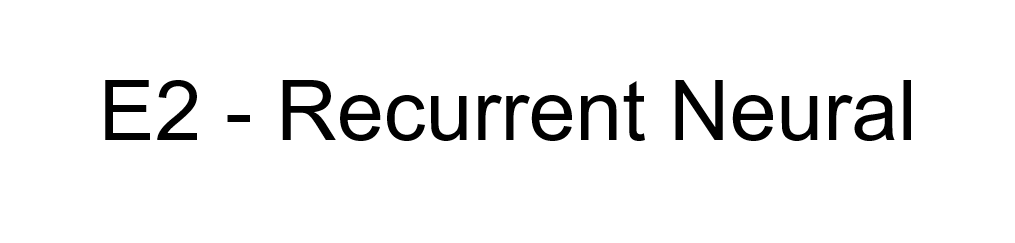

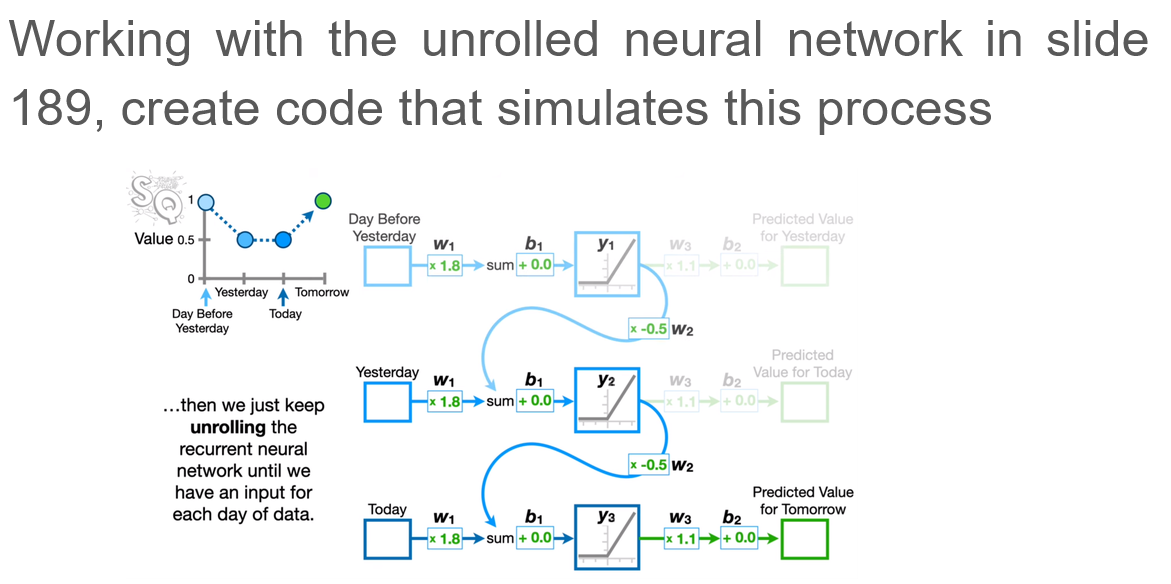

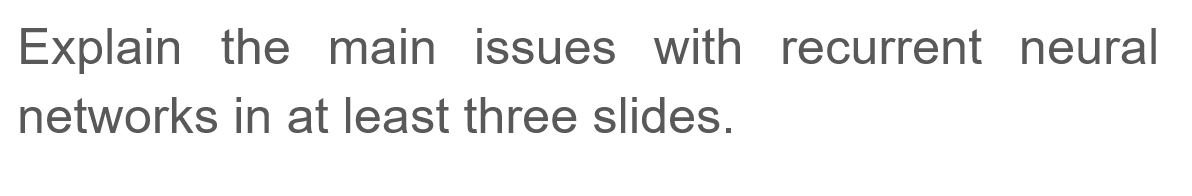

### Conceitos
Esta seção explica, um a um, os conceitos teóricos por trás da simulação da rede recorrente (RNN) apresentada no slide e implementada em código.

---

#### Rede Neural Recorrente (RNN — *Recurrent Neural Network*)

É um tipo de rede neural criada para trabalhar com **dados sequenciais** (séries temporais, texto, áudio, etc.), onde a ordem dos dados importa. Diferente de uma rede neural comum (*feedforward*), a RNN possui uma **conexão recorrente**: a saída calculada em um passo de tempo é reutilizada como entrada no passo seguinte. Isso permite que a rede "carregue" informação de um instante para o próximo, funcionando como uma forma simples de memória.

Na questão, a RNN é usada para prever o **valor de amanhã** com base nos valores de **anteontem**, **ontem** e **hoje**.

---

#### Desenrolamento (*Unrolling*)

"Desenrolar" uma RNN significa desenhar/representar explicitamente **uma cópia da mesma célula recorrente para cada passo de tempo** da sequência, em vez de representá-la como um único bloco com um laço (loop) fechado sobre si mesmo.

No slide, em vez de um único diagrama com uma seta saindo e voltando para a mesma caixa, temos **três blocos separados** (um para anteontem, um para ontem, um para hoje), conectados em sequência. Isso deixa mais fácil visualizar como a informação flui passo a passo, embora, na prática, seja **a mesma célula/os mesmos pesos** sendo reaplicados repetidamente.

---

#### Passo de Tempo (*Time Step*)

Cada "rodada" de cálculo da RNN, correspondente a um elemento da sequência de entrada. Na questão, existem 3 passos de tempo:

| Passo | Corresponde a |
|---|---|
| 1 | Anteontem (*Day Before Yesterday*) |
| 2 | Ontem (*Yesterday*) |
| 3 | Hoje (*Today*) |

---

#### Entrada (*Input*) — `x`

É o valor numérico fornecido à rede em cada passo de tempo (o valor da série naquele dia). No código, são as variáveis `anteontem`, `ontem` e `hoje`.

---

#### Peso `w1`

Número que **multiplica a entrada** `x` de cada passo de tempo. Ele indica a "importância"/escala que a rede dá ao valor de entrada daquele dia. No slide, `w1 = 1.8`, e é o **mesmo valor usado em todos os passos de tempo** (peso compartilhado).

---

#### Viés (*Bias*) — `b1`

Um valor constante somado ao resultado da soma ponderada, antes da ativação. Funciona como um "ajuste fino" que desloca o resultado para cima ou para baixo, independente da entrada. No slide, `b1 = 0.0`.

---

#### Soma Ponderada (*Weighted Sum*)

É o cálculo `soma = x · w1 + y_anterior · w2 + b1`, ou seja, a combinação linear entre a entrada atual, o estado recorrente vindo do passo anterior e o viés. É o valor que entra na função de ativação em seguida.

---

#### Função de Ativação (ReLU)

Função não linear aplicada ao resultado da soma ponderada, responsável por dar à rede a capacidade de aprender padrões não lineares (sem ela, empilhar camadas lineares equivaleria a uma única camada linear).

A **ReLU** (*Rectified Linear Unit*) é definida como:

```
ReLU(x) = max(0, x)
```

Ou seja: se o valor for negativo, vira 0; se for positivo, permanece igual. É a função representada pelo pequeno gráfico "dobrado na origem" dentro das caixas `y1`, `y2`, `y3` no slide.

---

#### Estado Recorrente / Saída Oculta — `y_t`

É a saída da função de ativação em cada passo de tempo (`y1`, `y2`, `y3`). Esse valor tem um papel duplo:

1. É o resultado "daquele passo" da rede;
2. É **reutilizado como entrada no próximo passo de tempo**, multiplicado por `w2` — é essa realimentação que caracteriza a "memória" da RNN.

---

#### Peso Recorrente — `w2`

Peso que multiplica o estado (`y`) vindo do passo de tempo **anterior**, antes de somá-lo à entrada do passo atual. É ele quem controla o quanto do "passado" influencia o cálculo do presente. No slide, `w2 = -0.5` (um valor negativo, ou seja, o estado anterior tem um efeito de **redução** sobre a soma atual).

> No primeiro passo de tempo (anteontem) não existe estado anterior, então esse termo simplesmente não entra no cálculo (equivale a considerar `y0 = 0`).

---

#### Compartilhamento de Pesos (*Weight Sharing*)

Característica fundamental das RNNs: os pesos `w1`, `b1` e `w2` são **os mesmos números em todos os passos de tempo** — não existe um `w1` diferente para cada dia. Isso é o que permite que a rede seja "desenrolada" para qualquer tamanho de sequência sem precisar de novos parâmetros, e é a diferença central em relação a uma rede feedforward comum (onde cada camada tem seus próprios pesos, independentes das demais).

---

#### Camada de Saída Final — `w3` e `b2`

Depois do último passo de tempo (hoje), o valor `y3` passa por uma transformação linear extra, exclusiva para gerar a previsão final:

```
Predicted Value for Tomorrow = y3 · w3 + b2
```

No slide, essa camada só é "ativada" (colorida) no último passo — nos passos anteriores, ela aparece esmaecida, porque a rede *poderia* calcular uma previsão para "ontem" ou "hoje" também, mas isso não é útil, já que esses valores já são conhecidos.

---

#### Predição / Valor Previsto (*Predicted Value*)

É a saída final da rede — o valor estimado para o próximo elemento da sequência (o dia de amanhã), calculado a partir de todas as informações passadas processadas passo a passo pela RNN.

---


### Slide

[Link para o Slide](https://drive.google.com/file/d/1fPp-7eha9UctrNtYVMhZlBi6wf8iwQ5j/view?usp=sharing)

### Código

#### Pesos

In [ ]:
# Esses pesos são usados entre todos os passos de tempo.
# É exatamente isso que caracteriza uma rede recorrente: a mesma
# "célula" (mesmos w1, b1, w2) é reutilizada para cada dia.

# peso aplicado na entrada (x) de cada dia
w1 = torch.tensor(1.8)
# viés somado antes da ativação
b1 = torch.tensor(0.0)
# peso da conexão recorrente (liga y do passo anterior ao próximo)
w2 = torch.tensor(-0.5)

# Pesos usados apenas no final, depois do último passo de tempo,
# para transformar y3 na previsão de amanhã
w3 = torch.tensor(1.1)
b2 = torch.tensor(0.0)

#### Função de Ativação

In [ ]:
# O pequeno gráfico dentro das caixas y1, y2, y3 no slide mostra
# uma curva "dobrada" na origem (0 para valores negativos, depois
# cresce linearmente) -> isso é a função ReLU, a mesma ativação
# usada na rede da atividade anterior.

def ativacao(x):
    return F.relu(x)

#### Dados de Entrada

In [ ]:
# Dados de entrada (valores dos três dias)
# Valores no eixo Y (0 a 1)

# "Day Before Yesterday"
anteontem = torch.tensor(1.0)
# "Yesterday"
ontem     = torch.tensor(0.4)
# "Today"
hoje      = torch.tensor(0.4)

print(f"Anteontem = {anteontem.item()}")
print(f"Ontem     = {ontem.item()}")
print(f"Hoje      = {hoje.item()}")

Anteontem = 1.0
Ontem     = 0.4000000059604645
Hoje      = 0.4000000059604645


#### Antes de Ontem

In [ ]:
# Passo de tempo 1 -> calcula y1
# sum1 = (entrada do dia) * w1 + b1

# (não existe conexão recorrente aqui, pois é o primeiro passo)
sum1 = anteontem * w1 + b1

# y1 = ativação aplicada à soma
y1 = ativacao(sum1)

print(f"sum1 = {sum1.item():.4f}")
print(f"y1   = {y1.item():.4f}")

sum1 = 1.8000
y1   = 1.8000


#### Ontem

In [ ]:
# Passo de tempo 2 -> calcula y2

# sum2 = (entrada do dia) * w1 + (y do passo anterior) * w2 + b1
sum2 = ontem * w1 + y1 * w2 + b1

# y2 = ativação aplicada à soma
y2 = ativacao(sum2)

print(f"sum2 = {sum2.item():.4f}")
print(f"y2   = {y2.item():.4f}")

sum2 = -0.1800
y2   = 0.0000


#### Hoje

In [ ]:
# Passo de tempo 3 -> calcula y3

# sum3 = (entrada do dia) * w1 + (y do passo anterior) * w2 + b1
sum3 = hoje * w1 + y2 * w2 + b1

# y3 = ativação aplicada à soma
y3 = ativacao(sum3)

print(f"sum3 = {sum3.item():.4f}")
print(f"y3   = {y3.item():.4f}")

sum3 = 0.7200
y3   = 0.7200


#### Previsão Amanhã

In [ ]:
# Camada de saída -> Previsão para amanhã

# Só aplicamos essa camada final no último passo de tempo (y3)
predicted_tomorrow = y3 * w3 + b2

print(f"Predicted Value for Tomorrow = {predicted_tomorrow.item():.4f}")

Predicted Value for Tomorrow = 0.7920


#### Passos

In [ ]:
# Resumo de todos os passos calculados

print("Resultados Passo a Passo")
print("-" * 40)
print(f"Passo 1 (Anteontem): x={anteontem.item():.2f} -> y1={y1.item():.4f}")
print(f"Passo 2 (Ontem):     x={ontem.item():.2f} -> y2={y2.item():.4f}")
print(f"Passo 3 (Hoje):      x={hoje.item():.2f} -> y3={y3.item():.4f}")
print("-" * 40)
print(f"Previsão para Amanhã = {predicted_tomorrow.item():.4f}")

Resultados Passo a Passo
----------------------------------------
Passo 1 (Anteontem): x=1.00 -> y1=1.8000
Passo 2 (Ontem):     x=0.40 -> y2=0.0000
Passo 3 (Hoje):      x=0.40 -> y3=0.7200
----------------------------------------
Previsão para Amanhã = 0.7920


## F2 ) Exploring word embeddings

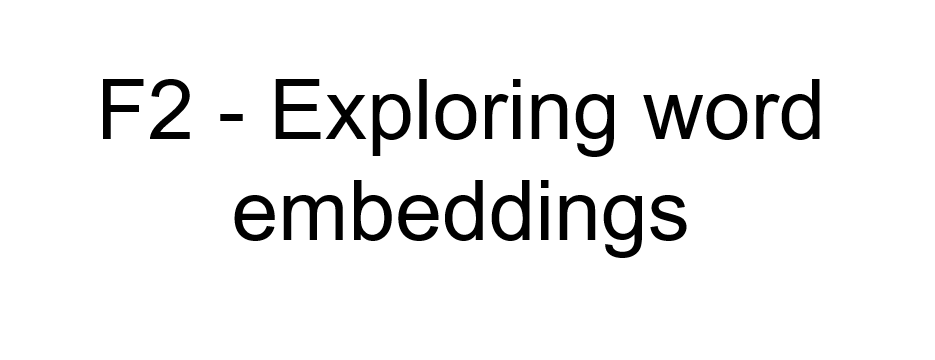

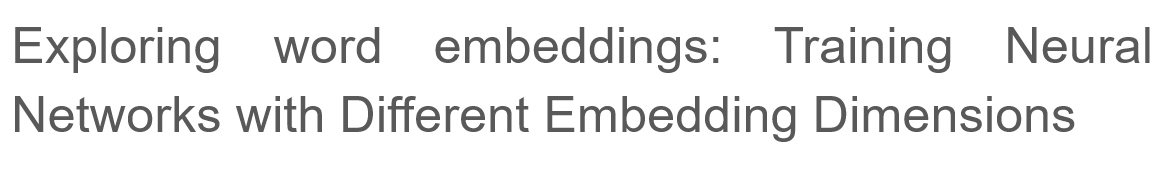

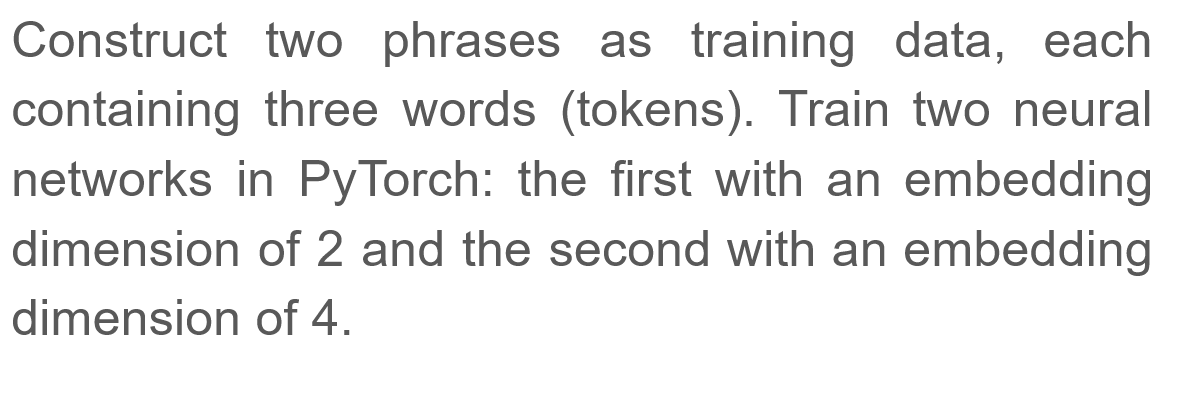

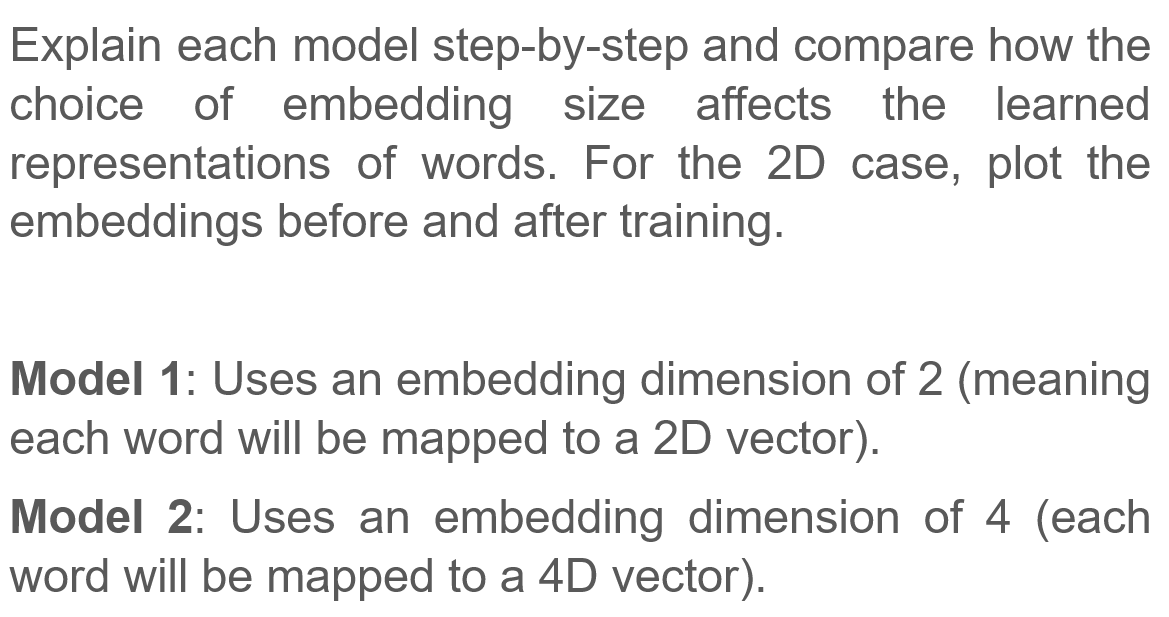

### Processamento de Linguagem Natural (PLN)

O Processamento de Linguagem Natural (PLN) é uma área da Inteligência Artificial que estuda técnicas para que computadores possam compreender, interpretar e gerar linguagem humana. Uma das etapas mais importantes em PLN é transformar palavras em representações numéricas para que possam ser processadas por algoritmos de aprendizado de máquina.

---

### Tokenização

A tokenização é o processo de dividir um texto em unidades menores chamadas **tokens**. Geralmente, cada palavra é considerada um token.

Exemplo:

Frase:

```
gato bebe leite
```

Após a tokenização:

```
["gato", "bebe", "leite"]
```

Cada palavra passa a ser tratada individualmente pelo modelo.

---

### Vocabulário

O vocabulário é o conjunto de todas as palavras distintas presentes no conjunto de treinamento.

Exemplo:

Frases:

```
gato bebe leite
cachorro bebe agua
```

Vocabulário:

```
agua
bebe
cachorro
gato
leite
```

Cada palavra recebe um identificador numérico (índice), permitindo que seja utilizada pela rede neural.

---


### Embeddings

Os embeddings são representações vetoriais das palavras. Em vez de utilizar apenas um número inteiro para representar uma palavra, cada palavra passa a ser representada por um vetor de números reais.

Exemplo:

```
gato → [0.23, -0.81]
```

ou

```
gato → [0.42, -0.18, 0.67, 1.05]
```

Esses vetores são aprendidos automaticamente durante o treinamento da rede neural.

---

### Dimensão do Embedding

A dimensão do embedding corresponde à quantidade de valores presentes no vetor que representa cada palavra.

Neste trabalho são utilizados dois modelos:

- **Embedding de dimensão 2:** cada palavra é representada por dois valores.
- **Embedding de dimensão 4:** cada palavra é representada por quatro valores.

Quanto maior a dimensão, maior a capacidade do modelo de representar características e relações entre as palavras. Entretanto, embeddings maiores também exigem mais parâmetros e maior custo computacional.

---


### Rede Neural

A rede neural utilizada possui duas camadas principais:

- **Camada de Embedding:** converte os índices das palavras em vetores numéricos.
- **Camada Linear (Fully Connected):** utiliza esses vetores para prever a palavra de saída.

Durante o treinamento, tanto os pesos da camada linear quanto os embeddings são ajustados automaticamente.

---

### Forward Propagation

O processo de *forward propagation* consiste em enviar os dados de entrada pela rede neural.

Neste exercício, as duas primeiras palavras da frase são fornecidas como entrada. A rede gera uma previsão para a terceira palavra.

Exemplo:

Entrada:

```
gato bebe
```

Saída esperada:

```
leite
```

---

### Função de Perda (Loss Function)

A função de perda mede o erro entre a previsão da rede neural e a resposta correta.

Foi utilizada a função **CrossEntropyLoss**, bastante empregada em problemas de classificação. Seu objetivo é indicar o quão distante a previsão do modelo está da resposta esperada.

Quanto menor o valor da perda, melhor é o desempenho da rede.

---


### Otimizador

O treinamento utiliza o otimizador **Adam (Adaptive Moment Estimation)**.

Sua função é atualizar os pesos da rede neural e os embeddings de forma a reduzir gradualmente o erro calculado pela função de perda.

---

### Épocas (Epochs)

Uma época corresponde a uma passagem completa por todos os exemplos do conjunto de treinamento.

Durante cada época:

1. As entradas são processadas.
2. A perda é calculada.
3. O algoritmo realiza o ajuste dos pesos.

Ao longo das épocas, espera-se que a perda diminua e que os embeddings passem a representar melhor as relações entre as palavras.

---



### Visualização dos Embeddings

Quando os embeddings possuem dimensão 2, é possível representá-los em um plano cartesiano.

Foram gerados dois gráficos:

- Antes do treinamento
- Depois do treinamento

Inicialmente, os vetores possuem valores aleatórios. Após o treinamento, espera-se que palavras relacionadas apresentem posições mais organizadas no espaço vetorial, refletindo o conhecimento aprendido pela rede.

No caso do embedding de dimensão 4, essa visualização direta não é possível, pois cada palavra é representada em um espaço de quatro dimensões.

### Código

#### Reprodutibilidade do código

In [ ]:
# Para que os resultados sejam reproduzíveis
torch.manual_seed(42)

#### Criação do Vocabulário

In [ ]:
# Frases utilizadas
frases = [["tigre", "come", "peixe"], ["lontra", "devora", "lagostin"]]

# Descobre todas as palavras diferentes existentes nas frases
vocabulario = sorted(set(palavra for frase in frases for palavra in frase))

print("Vocabulário:")
print(vocabulario)

# Associa cada palavra a um número
palavra_para_indice = { palavra: indice for indice, palavra in enumerate(vocabulario)}

indice_para_palavra = { indice: palavra for palavra, indice in palavra_para_indice.items()}

print("\nPalavra -> Índice")
print(palavra_para_indice)

Vocabulário:
['come', 'devora', 'lagostin', 'lontra', 'peixe', 'tigre']

Palavra -> Índice
{'come': 0, 'devora': 1, 'lagostin': 2, 'lontra': 3, 'peixe': 4, 'tigre': 5}


#### Tratamento dos Dados

In [ ]:
# A entrada será composta pelas duas primeiras palavras.
# A saída será a terceira palavra.

dados_treinamento = []

for frase in frases:

    entrada = [palavra_para_indice[frase[0]], palavra_para_indice[frase[1]]]

    saida = palavra_para_indice[frase[2]]

    dados_treinamento.append((entrada, saida))

print(dados_treinamento)

[([5, 0], 4), ([3, 1], 2)]


#### Rede Neural

In [ ]:
class RedeEmbeddings(nn.Module):

    def __init__(self, tamanho_vocabulario, dimensao_embedding):

        super().__init__()

        # Camada de embeddings
        self.embedding = nn.Embedding(tamanho_vocabulario, dimensao_embedding)

        # Camada totalmente conectada
        self.linear = nn.Linear(dimensao_embedding * 2, tamanho_vocabulario)

    def forward(self, entrada):

        # Converte índices em vetores
        vetor = self.embedding(entrada)

        # Junta os dois vetores em apenas um
        vetor = vetor.view(1, -1)

        # Faz a classificação
        saida = self.linear(vetor)

        return saida

#### Função de Treino

In [ ]:
def treinar_modelo(dimensao_embedding, epocas=300):

    modelo = RedeEmbeddings(len(vocabulario), dimensao_embedding)

    funcao_perda = nn.CrossEntropyLoss()

    otimizador = optim.Adam(modelo.parameters(), lr=0.05)

    # Guarda os embeddings antes do treinamento
    embeddings_antes = modelo.embedding.weight.detach().numpy().copy()

    historico_perda = []

    for epoca in range(epocas):

        perda_total = 0

        for entrada, saida in dados_treinamento:

            entrada = torch.tensor(entrada, dtype=torch.long)

            saida = torch.tensor([saida], dtype=torch.long)

            otimizador.zero_grad()

            previsao = modelo(entrada)

            perda = funcao_perda(previsao, saida)

            perda.backward()

            otimizador.step()

            perda_total += perda.item()

        historico_perda.append(perda_total)

    embeddings_depois = modelo.embedding.weight.detach().numpy().copy()

    return modelo, embeddings_antes, embeddings_depois, historico_perda

#### Primeiro Modelo

In [ ]:
# MODELO 1
# EMBEDDING COM DUAS DIMENSÕES

modelo2d, antes2d, depois2d, perdas2d = treinar_modelo(2)

print("Treinamento finalizado!")

Treinamento finalizado!


#### Gráfico Comparativo

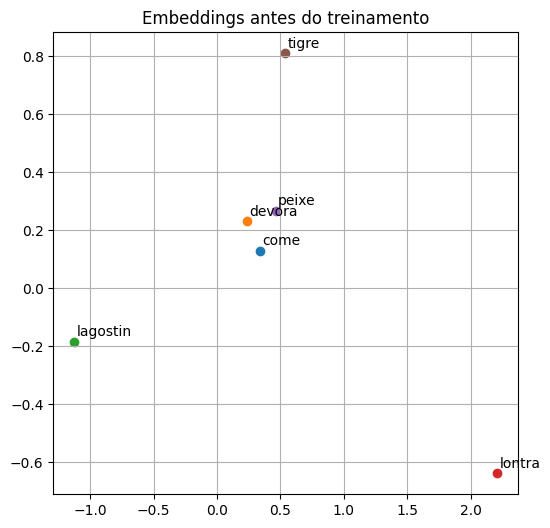

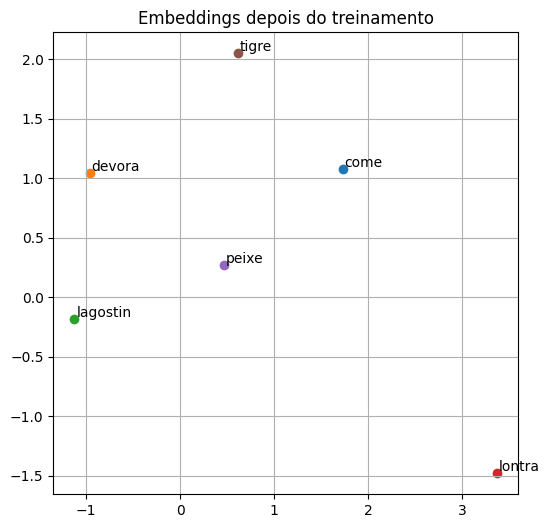

In [ ]:
def desenhar_embeddings(embeddings, titulo):

    plt.figure(figsize=(6,6))

    for indice, palavra in enumerate(vocabulario):

        x = embeddings[indice][0]
        y = embeddings[indice][1]

        plt.scatter(x, y)

        plt.text(x + 0.02,y + 0.02, palavra, fontsize=10)

    plt.title(titulo)
    plt.grid(True)
    plt.show()


desenhar_embeddings(antes2d, "Embeddings antes do treinamento")

desenhar_embeddings(depois2d, "Embeddings depois do treinamento")

#### Gráfico de Perda

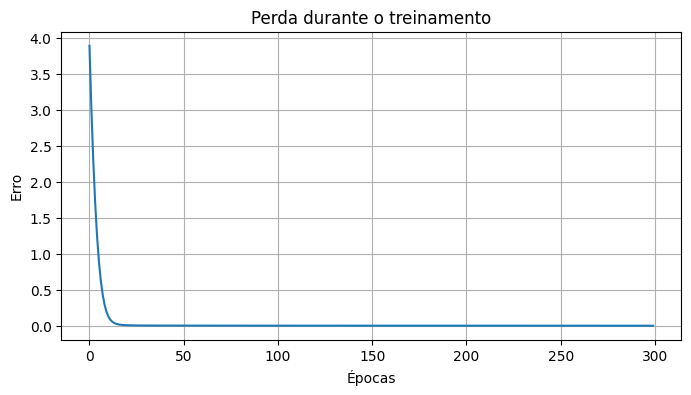

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(perdas2d)
plt.title("Perda durante o treinamento")

plt.xlabel("Épocas")
plt.ylabel("Erro")

plt.grid(True)
plt.show()

#### Segundo Modelo

In [ ]:
# MODELO 2
# EMBEDDING COM QUATRO DIMENSÕES

modelo4d, antes4d, depois4d, perdas4d = treinar_modelo(4)

print("Treinamento finalizado!")

Treinamento finalizado!


#### Exibição dos Embeddings aprendidos

In [ ]:
# EMBEDDINGS APRENDIDOS

print("Vetores aprendidos pelo modelo:\n")

for indice, palavra in enumerate(vocabulario):

    print(f"{palavra}:")
    print(depois4d[indice])
    print()

Vetores aprendidos pelo modelo:

come:
[-0.39411038 -0.626678   -1.7303023  -0.6452797 ]

devora:
[ 2.046773    1.2955891   1.3288755  -0.30072322]

lagostin:
[ 0.33832297  1.6991702   0.01086814 -0.33874235]

lontra:
[-1.0293136  -0.52011657  1.6160249   1.0157973 ]

peixe:
[-1.4691501  1.4331553  0.743952  -0.4815844]

tigre:
[-2.0843427  1.1431056 -1.6124625 -1.1659049]

